In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

2026-05-20 15:21:27.647368: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779290488.066636      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779290488.187150      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779290489.161360      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779290489.161419      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779290489.161426      57 computation_placer.cc:177] computation placer alr

In [6]:
CSV_PATH  = '/kaggle/input/datasets/rightway11/state-farm-distracted-driver-detection/driver_imgs_list.csv'
TRAIN_DIR = '/kaggle/input/datasets/rightway11/state-farm-distracted-driver-detection/imgs/train/'

df = pd.read_csv(CSV_PATH)
df['filepath'] = df['classname'] + '/' + df['img']
df['filepath'] = TRAIN_DIR + df['filepath']

# Map to 3 classes
class_map = {'c0': 'safe', 'c1': 'texting', 'c3': 'texting', 'c2': 'calling', 'c4': 'calling'}
df = df[df['classname'].isin(class_map.keys())].copy()
df['label'] = df['classname'].map(class_map)

# Split by DRIVER, not by image
unique_drivers = df['subject'].unique()
train_drivers, val_drivers = train_test_split(unique_drivers, test_size=0.2, random_state=42)

train_df = df[df['subject'].isin(train_drivers)].reset_index(drop=True)
val_df   = df[df['subject'].isin(val_drivers)].reset_index(drop=True)

print(f"Train: {len(train_drivers)} drivers → {len(train_df):,} images")
print(f"Val:   {len(val_drivers)} drivers → {len(val_df):,} images")
print(f"Driver overlap (must be 0): {len(set(train_df['subject']) & set(val_df['subject']))}")
print(f"\nClass distribution:\n{train_df['label'].value_counts()}")

Train: 20 drivers → 9,139 images
Val:   6 drivers → 2,606 images
Driver overlap (must be 0): 0

Class distribution:
label
calling    3611
texting    3603
safe       1925
Name: count, dtype: int64


In [7]:
IMG_SIZE   = 260
BATCH_SIZE = 32

# Forces consistent label order: 0=safe, 1=texting, 2=calling
TARGET_CLASSES = ['safe', 'texting', 'calling']

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=TARGET_CLASSES,
    shuffle=False
)

# MUST print: {'safe': 0, 'texting': 1, 'calling': 2}
print("Class indices:", train_gen.class_indices)

Found 9139 validated image filenames belonging to 3 classes.
Found 2606 validated image filenames belonging to 3 classes.
Class indices: {'safe': 0, 'texting': 1, 'calling': 2}


In [8]:
base_model = EfficientNetB2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Phase 1: freeze the entire base
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Count trainable vs frozen layers
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen    = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
print(f"Trainable params:  {trainable:,}")
print(f"Frozen params:     {frozen:,}")

I0000 00:00:1779290757.596970      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779290757.603133      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params:  4,227
Frozen params:     7,768,569


In [9]:
from sklearn.utils.class_weight import compute_class_weight

# Handle class imbalance
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(TARGET_CLASSES),
    y=train_df['label']
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\n=== PHASE 1: Training head only (base frozen) ===")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_phase1,
    class_weight=class_weights
)

Class weights: {0: np.float64(1.5825108225108224), 1: np.float64(0.8454991211027847), 2: np.float64(0.8436259577217761)}

=== PHASE 1: Training head only (base frozen) ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1779290809.848844     146 service.cc:152] XLA service 0x7f29fc219a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779290809.848884     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779290809.848888     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779290813.077207     146 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-20 15:27:05.062701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 15:27:05.211997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 15:27:05.587623: E external/local_xl

 76/286 ━━━━━━━━━━━━━━━━━━━━ 3:09 904ms/step - accuracy: 0.4294 - loss: 1.1105

2026-05-20 15:28:37.710050: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 15:28:37.853176: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 15:28:38.194496: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 15:28:38.338840: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 15:28:38.482081: E external/local_xla/xla/stream_

286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.5473 - loss: 0.9453

2026-05-20 15:32:36.564707: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 15:32:36.705390: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 15:32:37.028389: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 15:32:37.175080: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-20 15:32:37.318695: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.73561, saving model to best_model_phase1.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - accuracy: 0.5477 - loss: 0.9447 - val_accuracy: 0.7356 - val_loss: 0.6241 - learning_rate: 0.0010
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.7984 - loss: 0.5492
Epoch 2: val_accuracy improved from 0.73561 to 0.74904, saving model to best_model_phase1.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 190s 665ms/step - accuracy: 0.7984 - loss: 0.5491 - val_accuracy: 0.7490 - val_loss: 0.5597 - learning_rate: 0.0010
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.8266 - loss: 0.4789
Epoch 3: val_accuracy improved from 0.74904 to 0.76861, saving model to best_model_phase1.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 186s 649ms/step - accuracy: 0.8266 - loss: 0.4789 - val_accuracy: 0.7686 - val_loss: 0.5343 - learning_rate: 0.0010
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.8336 - loss: 0.4378
Epoch 4: val_accur

In [11]:

# Unfreeze last 30 layers only
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile with very low learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7),
    ModelCheckpoint('best_model_final.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("=== PHASE 2: Fine-tuning last 30 layers ===")
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks_phase2,
    class_weight=class_weights
)

=== PHASE 2: Fine-tuning last 30 layers ===
Epoch 1/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.9410 - loss: 0.1620
Epoch 1: val_accuracy improved from -inf to 0.84881, saving model to best_model_final.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 270s 809ms/step - accuracy: 0.9410 - loss: 0.1620 - val_accuracy: 0.8488 - val_loss: 0.3803 - learning_rate: 1.0000e-05
Epoch 2/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.9515 - loss: 0.1406
Epoch 2: val_accuracy improved from 0.84881 to 0.85764, saving model to best_model_final.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 187s 652ms/step - accuracy: 0.9515 - loss: 0.1406 - val_accuracy: 0.8576 - val_loss: 0.3515 - learning_rate: 1.0000e-05
Epoch 3/15
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.9537 - loss: 0.1313
Epoch 3: val_accuracy improved from 0.85764 to 0.86915, saving model to best_model_final.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 187s 654ms/step - accuracy: 0.9537 - loss: 0.1312 - val_accuracy: 0.8691 - val_loss

82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - accuracy: 0.9434 - loss: 0.1586

Final Val Loss: 0.2705
Final Val Accuracy: 0.8922
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 224ms/step


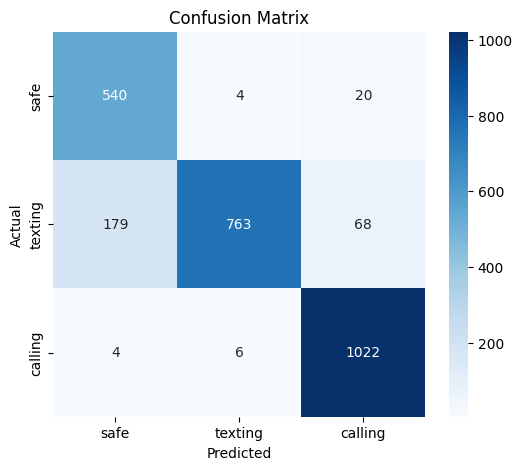

              precision    recall  f1-score   support

        safe       0.75      0.96      0.84       564
     texting       0.99      0.76      0.86      1010
     calling       0.92      0.99      0.95      1032

    accuracy                           0.89      2606
   macro avg       0.88      0.90      0.88      2606
weighted avg       0.91      0.89      0.89      2606



In [12]:
loss, acc = model.evaluate(val_gen)
print(f"\nFinal Val Loss: {loss:.4f}")
print(f"Final Val Accuracy: {acc:.4f}")

# Confusion matrix
val_gen.reset()
preds = model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES))

In [13]:
model.save('/kaggle/working/best_model_final.h5')
print(f"Saved: {os.path.getsize('/kaggle/working/best_model_final.h5')/1e6:.1f} MB")

Saved: 56.0 MB


In [4]:
IMG_SIZE = (192, 192) 
class_labels = ['Safe', 'Texting', 'Calling']
IMAGE_FOLDER = '/kaggle/input/datasets/hanamostafa05/moaaz-test'

fig = plt.figure(figsize=(16, 12))
count = 1

print(f"[*] Scanning folder: {IMAGE_FOLDER}")

for filename in os.listdir(IMAGE_FOLDER):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(IMAGE_FOLDER, filename)
        
        original_img = cv2.imread(img_path)
        if original_img is None: 
            continue
        img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        
        resized_img = cv2.resize(img_rgb, (IMG_SIZE[1], IMG_SIZE[0]))
        
        input_array = np.expand_dims(resized_img, axis=0).astype('float32')
        
        input_array = preprocess_input(input_array)
        
        preds = model.predict(input_array, verbose=0)[0]
        
        idx = np.argmax(preds)
        winner_conf = preds[idx] * 100
        winner_label = class_labels[idx]
        
        stats_text = (f"Safe: {preds[0]*100:.1f}%\n"
                      f"Texting: {preds[1]*100:.1f}%\n"
                      f"Calling: {preds[2]*100:.1f}%")
        
        plt.subplot(3, 4, count) 
        plt.imshow(resized_img)
        
        text_color = 'green' if winner_label == 'Safe' else 'red'
        plt.title(f"{winner_label}", color=text_color, fontweight='bold', fontsize=12)
        plt.text(0, IMG_SIZE[1] + 40, stats_text, fontsize=10, 
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        plt.axis('off')
        
        count += 1
        if count > 12: 
            break

plt.tight_layout()
plt.show()
this is my code for it

SyntaxError: invalid syntax (3973240838.py, line 50)